# 03 — Feature Engineering
## IFTA Audit ML Pipeline — Government of Alberta
**AWS:** S3, Textract AnalyzeExpense  
**Output:** features/features.csv, features/jurisdiction_summary.csv, features/monthly_trends.csv, features/weekly_trends.csv

### Cell 1 — Setup & load curated data

In [1]:
import subprocess
subprocess.run(["pip","install","-q","shap","scikit-learn","matplotlib","seaborn","boto3","scipy"], check=True)

import boto3, re, warnings, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
from io import StringIO, BytesIO
from dateutil import parser as dparser

s3       = boto3.client("s3",       region_name="ca-central-1")
textract = boto3.client("textract", region_name="ca-central-1")
BUCKET   = "govofalbertaraw"

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
COLORS = {"normal":"#1a6fc4","anomaly":"#dc2626","warning":"#f59e0b","ok":"#16a34a","gray":"#9ca3af"}

def load_csv(key):
    obj = s3.get_object(Bucket=BUCKET, Key=key)
    return pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))

def save_csv(dataframe, key):
    buffer = StringIO()
    dataframe.to_csv(buffer, index=False)
    buffer.seek(0)
    s3.put_object(Bucket=BUCKET, Key=key, Body=buffer.getvalue().encode("utf-8"), ContentType="text/csv")
    print(f"✅ Saved → s3://{BUCKET}/{key}")

df = load_csv("curated/ml_ready.csv")
df["date_clean"] = pd.to_datetime(df["date_clean"], errors="coerce")
print(f"✅ Loaded {len(df)} rows | Provinces: {df['province_from'].value_counts().to_dict()}")

✅ Loaded 40 rows | Provinces: {'AB': 15, 'BC': 13, 'ON': 6, 'MB': 4, 'SK': 2}


### Cell 2 — Re-run Textract AnalyzeExpense for structured invoice joining

In [2]:
def analyze_expense(bucket, key):
    return textract.analyze_expense(Document={"S3Object":{"Bucket":bucket,"Name":key}})

def parse_expense_response(response, source_key):
    invoice = {"source_file":source_key,"vendor_name":None,"transaction_date":None,
               "total_cost":None,"fuel_litres":None,"price_per_litre":None,
               "fuel_type":None,"location_city":None,"location_province":None,"avg_confidence":None}
    confidences = []
    for doc in response.get("ExpenseDocuments",[]):
        for field in doc.get("SummaryFields",[]):
            ft   = field.get("Type",{}).get("Text","").upper()
            fv   = field.get("ValueDetection",{}).get("Text","")
            conf = field.get("ValueDetection",{}).get("Confidence",0)
            confidences.append(conf)
            if "VENDOR" in ft or "NAME" in ft:    invoice["vendor_name"]      = fv
            elif "DATE" in ft:                    invoice["transaction_date"] = fv
            elif "TOTAL" in ft or "AMOUNT" in ft: invoice["total_cost"]       = fv
            elif "ADDRESS" in ft or "CITY" in ft: invoice["location_city"]    = fv
        for group in doc.get("LineItemGroups",[]):
            for item in group.get("LineItems",[]):
                for field in item.get("LineItemExpenseFields",[]):
                    ft   = field.get("Type",{}).get("Text","").upper()
                    fv   = field.get("ValueDetection",{}).get("Text","")
                    conf = field.get("ValueDetection",{}).get("Confidence",0)
                    confidences.append(conf)
                    if "QUANTITY" in ft or "UNIT" in ft:      invoice["fuel_litres"]     = fv
                    elif "PRICE"  in ft or "UNIT_PRICE" in ft:invoice["price_per_litre"] = fv
                    elif "ITEM"   in ft or "DESC" in ft:      invoice["fuel_type"]       = fv
    invoice["avg_confidence"] = round(sum(confidences)/len(confidences),1) if confidences else 0
    return invoice

def clean_vendor(text):
    if pd.isna(text): return None
    text = re.sub(r'http\S+|www\.\S+','',str(text))
    return text.replace('\n',' ').strip() or None

def clean_cost(text):
    if pd.isna(text): return None
    m = re.search(r'\d+\.\d+',str(text))
    return float(m.group()) if m else None

def clean_date(text):
    if pd.isna(text): return None
    try: return pd.to_datetime(dparser.parse(str(text),dayfirst=False))
    except: return None

def extract_province(text):
    if pd.isna(text): return None, None
    m = re.search(r'([A-Za-z\s]+),?\s*(AB|BC|SK|MB|ON|QC|YT)',str(text),re.IGNORECASE)
    return (m.group(1).strip(), m.group(2).upper()) if m else (None, None)

# Load invoices from S3 
obj    = s3.get_object(Bucket=BUCKET, Key="progress/fuel_invoices.csv")
df_inv = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))
print(f"✅ Loaded {len(df_inv)} invoices from S3")
print(df_inv[["vendor_clean","date_clean","total_clean","inv_province"]].to_string())

✅ Loaded 12 invoices from S3
           vendor_clean  date_clean  total_clean inv_province
0       UFA.com/Ratells  2022-08-18          NaN           AB
1           51992798770         NaN        40.83           ON
2           58746321330  2016-06-03        55.16           ON
3   Car Northgate Eneu.  2023-01-07        45.42           BC
4      COSTCO WHOLESALE  2025-11-30        41.63           MB
5        (416)-496-2443  2023-06-21        30.00           ON
6          Esso Express  2024-04-11       150.00           AB
7        (678) 899-8989  2020-08-23        33.00           BC
8      petro-points.com  2021-05-08        59.43           ON
9    w.shell.ca/opinion  2016-05-04        33.00           BC
10      UFA.com/Ratells  2022-08-15          NaN           AB
11                  NaN  2016-04-30        31.00           BC


### Cell 3 — Join fuel invoices to distance trips

In [3]:
def join_invoices_to_trips(trips, invoices, date_window=1):
    """
    Join by province + date (±1 day).
    No direct key exists between invoices and trips.
    Both date columns forced to datetime to prevent type mismatch.
    Unmatched trips flagged as no_fuel_purchase — primary IFTA signal.
    """
    trips    = trips.copy()
    invoices = invoices.copy()
    trips["fuel_cost"]       = np.nan
    trips["fuel_litres_inv"] = np.nan
    trips["vendor"]          = None
    trips["inv_province"]    = None
    trips["fuel_match"]      = False

    # Force both to datetime — handles mixed format issue
    trips["date_clean"]    = pd.to_datetime(trips["date_clean"],   dayfirst=True, errors="coerce")
    invoices["date_clean"] = pd.to_datetime(invoices["date_clean"],dayfirst=False,errors="coerce")

    for idx, trip in trips.iterrows():
        trip_date     = trip["date_clean"]
        trip_province = trip["province_from"]
        if pd.isna(trip_date) or pd.isna(trip_province): continue
        candidates = invoices[
            (invoices["inv_province"] == trip_province) &
            (invoices["date_clean"].notna()) &
            (abs((invoices["date_clean"] - trip_date).dt.days) <= date_window)
        ]
        if not candidates.empty:
            best = candidates.iloc[0]
            trips.at[idx,"fuel_cost"]       = best["total_clean"]
            trips.at[idx,"fuel_litres_inv"] = best.get("fuel_litres",np.nan)
            trips.at[idx,"vendor"]          = best["vendor_clean"]
            trips.at[idx,"inv_province"]    = best["inv_province"]
            trips.at[idx,"fuel_match"]      = True
            print(f"  ✅ {trip['origin_clean']} → {trip['dest_clean']} | {best['vendor_clean']} | {trip_date.date()}")

    matched   = trips["fuel_match"].sum()
    unmatched = len(trips) - matched
    print(f"\n✅ Matched: {matched} | Unmatched: {unmatched} ← primary IFTA signal")
    return trips

df = join_invoices_to_trips(df, df_inv)

  ✅ Winnipeg → Brandon | COSTCO WHOLESALE | 2025-11-30
  ✅ Langley → Burnaby | (678) 899-8989 | 2020-08-23
  ✅ Willowdale → Caledon | (416)-496-2443 | 2023-06-21
  ✅ Kelowna → Langley | Car Northgate Eneu. | 2023-01-07
  ✅ Barrie → Willowdale | petro-points.com | 2021-05-08
  ✅ Red Deer → Edmonton | Esso Express | 2024-04-11
  ✅ Langley → Burnaby | w.shell.ca/opinion | 2016-05-04
  ✅ Burnaby → Langley | nan | 2016-04-30
  ✅ Consort → Kamloops | UFA.com/Ratells | 2022-08-15

✅ Matched: 9 | Unmatched: 31 ← primary IFTA signal


In [4]:
# ── Fix fuel_litres_inv — Textract returned price_per_litre
# instead of actual litres for most invoices
# Check invoices for correct litre values

obj    = s3.get_object(Bucket=BUCKET, Key="progress/fuel_invoices.csv")
df_inv = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))

print("Invoice fuel data check:")
print(df_inv[["vendor_clean","fuel_litres","price_per_litre","total_clean"]].to_string())

# fuel_litres < 5 almost certainly means price_per_litre was mis-mapped
# Real fuel purchases are 30-200 litres, never 1.0 or 1.6
print(f"\n⚠ Suspicious fuel_litres values (< 5L):")
print(df_inv[df_inv["fuel_litres"] < 5][["vendor_clean","fuel_litres","total_clean"]])

Invoice fuel data check:
           vendor_clean  fuel_litres  price_per_litre  total_clean
0       UFA.com/Ratells          NaN              NaN          NaN
1           51992798770       26.342            1.550        40.83
2           58746321330       35.587            1.550        55.16
3   Car Northgate Eneu.       29.303            1.550        45.42
4      COSTCO WHOLESALE       26.858            1.550        41.63
5        (416)-496-2443       18.416            1.629        30.00
6          Esso Express       94.399            1.589       150.00
7        (678) 899-8989       21.290            1.550        33.00
8      petro-points.com       47.204            1.259        59.43
9    w.shell.ca/opinion       21.290            1.550        33.00
10      UFA.com/Ratells          NaN              NaN          NaN
11                  NaN       20.000            1.550        31.00

⚠ Suspicious fuel_litres values (< 5L):
Empty DataFrame
Columns: [vendor_clean, fuel_litres, total_clea

### Cell 4 — Compute all 5 IFTA features

In [5]:
print("Computing 5 IFTA features...")
print("=" * 55)

# F1: Fuel litres per km
df["fuel_litres_final"]        = df["fuel_litres_inv"]
df["litres_per_km"]            = df["fuel_litres_final"] / df["dist_clean"].replace(0,np.nan)
df["implausible_litres_per_km"]= (df["litres_per_km"]<0.20)|(df["litres_per_km"]>0.80)
print(f"✅ F1 — litres_per_km | Implausible: {df['implausible_litres_per_km'].sum()}")

# F2: Fuel cost per km
df["fuel_cost"]      = pd.to_numeric(df["fuel_cost"], errors="coerce")
df["cost_per_km"]    = df["fuel_cost"] / df["dist_clean"].replace(0,np.nan)
median_cpk           = df["cost_per_km"].median()
df["high_cost_per_km"]= df["cost_per_km"] > median_cpk * 3
print(f"✅ F2 — cost_per_km | High cost: {df['high_cost_per_km'].sum()}")

# F3: No fuel purchase
df["no_fuel_purchase"] = ~df["fuel_match"]
print(f"✅ F3 — no_fuel_purchase | Unmatched: {df['no_fuel_purchase'].sum()}")

# F4: Jurisdiction imbalance
dist_by_prov = df.groupby("province_from")["dist_clean"].sum()
dist_pct     = dist_by_prov / dist_by_prov.sum()
fuel_by_prov = df.groupby("inv_province")["fuel_cost"].sum()
fuel_pct     = fuel_by_prov / fuel_by_prov.sum()
jurisdiction_summary = pd.DataFrame({"distance_pct":dist_pct,"fuel_pct":fuel_pct}).fillna(0)
jurisdiction_summary["imbalance"] = abs(jurisdiction_summary["distance_pct"]-jurisdiction_summary["fuel_pct"])
jurisdiction_summary["high_risk"] = jurisdiction_summary["imbalance"] > 0.15
imb_map = jurisdiction_summary["imbalance"].to_dict()
df["jurisdiction_imbalance"]      = df["province_from"].map(imb_map).fillna(0)
df["high_jurisdiction_imbalance"] = df["jurisdiction_imbalance"] > 0.15
print(f"✅ F4 — jurisdiction_imbalance | High risk: {df['high_jurisdiction_imbalance'].sum()}")

# F5: Temporal trends
df = df.sort_values("date_clean").reset_index(drop=True)
df["year"]        = df["date_clean"].dt.year
df["month"]       = df["date_clean"].dt.month
df["week"]        = df["date_clean"].dt.isocalendar().week.astype("Int64")
df["day_of_week"] = df["date_clean"].dt.day_name()
daily   = df.groupby("date_clean").size().reset_index(name="trips_per_day")
df      = df.merge(daily, on="date_clean", how="left")
monthly = df.groupby(["year","month"])["dist_clean"].sum().reset_index()
monthly.columns = ["year","month","monthly_km"]
weekly  = df.groupby("week")["fuel_cost"].sum().reset_index()
weekly.columns  = ["week","weekly_fuel_cost"]
print(f"✅ F5 — temporal trends | Months: {df['month'].nunique()} | Weeks: {df['week'].nunique()}")

Computing 5 IFTA features...
✅ F1 — litres_per_km | Implausible: 2
✅ F2 — cost_per_km | High cost: 0
✅ F3 — no_fuel_purchase | Unmatched: 31
✅ F4 — jurisdiction_imbalance | High risk: 0
✅ F5 — temporal trends | Months: 11 | Weeks: 20


### Cell 5 — Chart 1: Feature distributions

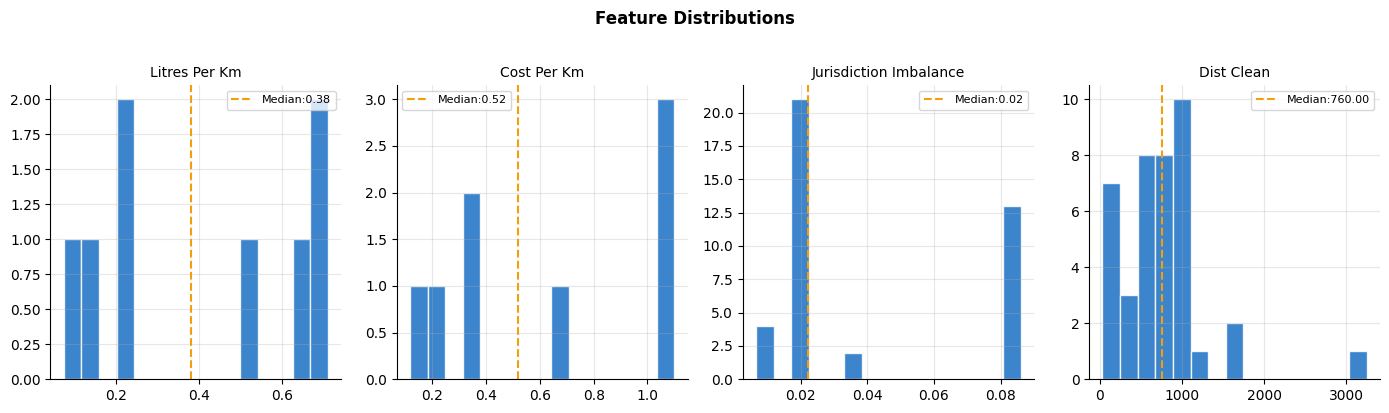

✅ Chart 1 saved


In [6]:
numeric_features = [f for f in ["litres_per_km","cost_per_km","jurisdiction_imbalance","dist_clean"] if f in df.columns]
fig, axes = plt.subplots(1,len(numeric_features),figsize=(14,4))
if len(numeric_features)==1: axes=[axes]
for ax,feat in zip(axes,numeric_features):
    data = df[feat].dropna()
    ax.hist(data,bins=15,color=COLORS["normal"],edgecolor="white",alpha=0.85)
    ax.axvline(data.median(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label=f"Median:{data.median():.2f}")
    ax.set_title(feat.replace("_"," ").title(),fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Feature Distributions",fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("feat_chart1_distributions.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

### Cell 6 — Chart 2: Fuel match by province

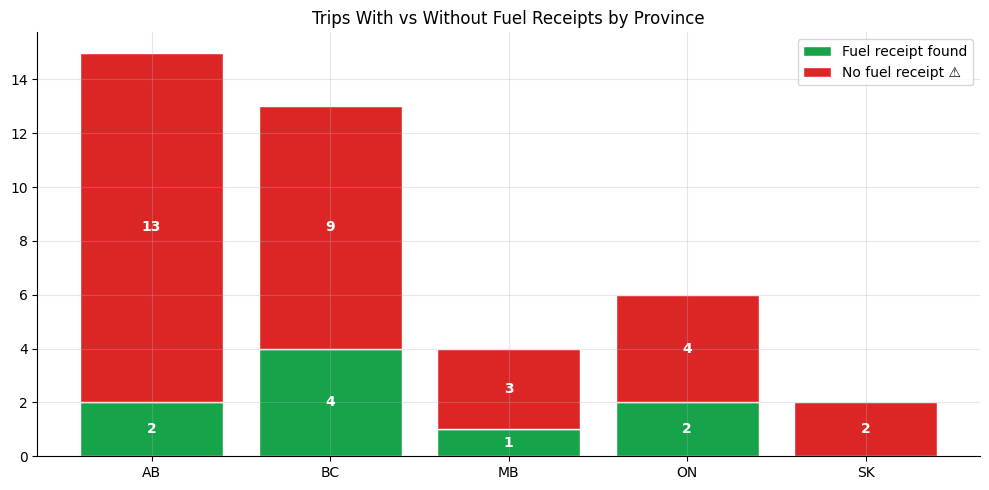

✅ Chart 2 saved


In [7]:
provinces = df.groupby("province_from").agg(matched=("fuel_match","sum"),total=("fuel_match","count")).reset_index()
provinces["unmatched"] = provinces["total"] - provinces["matched"]
fig, ax = plt.subplots(figsize=(10,5))
x = range(len(provinces))
ax.bar(x,provinces["matched"],color=COLORS["ok"],label="Fuel receipt found",edgecolor="white")
ax.bar(x,provinces["unmatched"],color=COLORS["anomaly"],label="No fuel receipt ⚠",edgecolor="white",bottom=provinces["matched"])
for i,row in provinces.iterrows():
    if row["matched"]>0:   ax.text(i,row["matched"]/2,str(int(row["matched"])),ha="center",va="center",color="white",fontweight="bold")
    if row["unmatched"]>0: ax.text(i,row["matched"]+row["unmatched"]/2,str(int(row["unmatched"])),ha="center",va="center",color="white",fontweight="bold")
ax.set_title("Trips With vs Without Fuel Receipts by Province")
ax.set_xticks(x); ax.set_xticklabels(provinces["province_from"])
ax.legend()
plt.tight_layout()
plt.savefig("feat_chart2_fuel_match.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

### Cell 7 — Chart 3: Jurisdiction imbalance

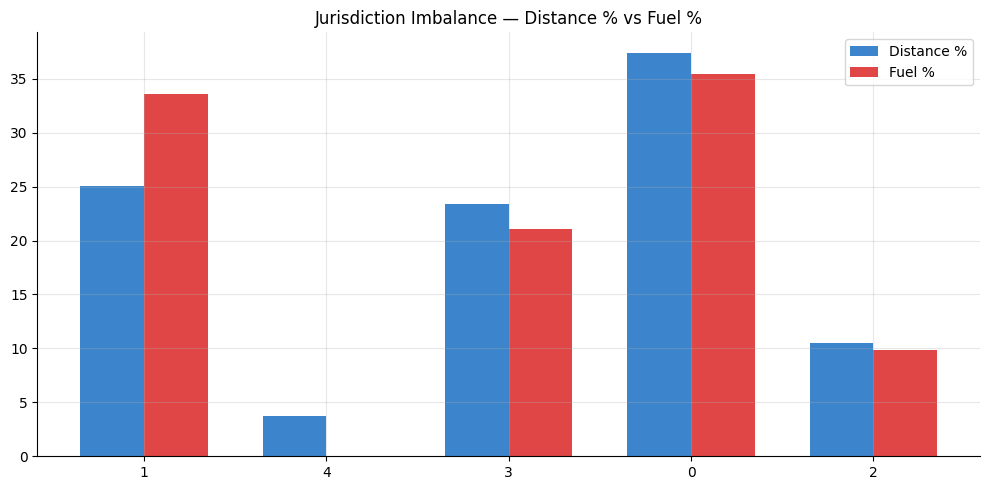

✅ Chart 3 saved


In [8]:
js    = jurisdiction_summary.reset_index()
js    = js[js["distance_pct"]>0].sort_values("imbalance",ascending=False)
x     = range(len(js))
width = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([i-width/2 for i in x],js["distance_pct"]*100,width,color=COLORS["normal"],label="Distance %",alpha=0.85)
ax.bar([i+width/2 for i in x],js["fuel_pct"]*100,width,color=COLORS["anomaly"],label="Fuel %",alpha=0.85)
for i,(_,row) in enumerate(js.iterrows()):
    if row["high_risk"]: ax.annotate("⚠ High risk",xy=(i,max(row["distance_pct"],row["fuel_pct"])*100+1),ha="center",color=COLORS["anomaly"],fontsize=9,fontweight="bold")
ax.set_title("Jurisdiction Imbalance — Distance % vs Fuel %")
ax.set_xticks(x); ax.set_xticklabels(js["province_from"] if "province_from" in js.columns else js.index)
ax.legend()
plt.tight_layout()
plt.savefig("feat_chart3_jurisdiction.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved")

### Cell 8 — Chart 4: Temporal trends

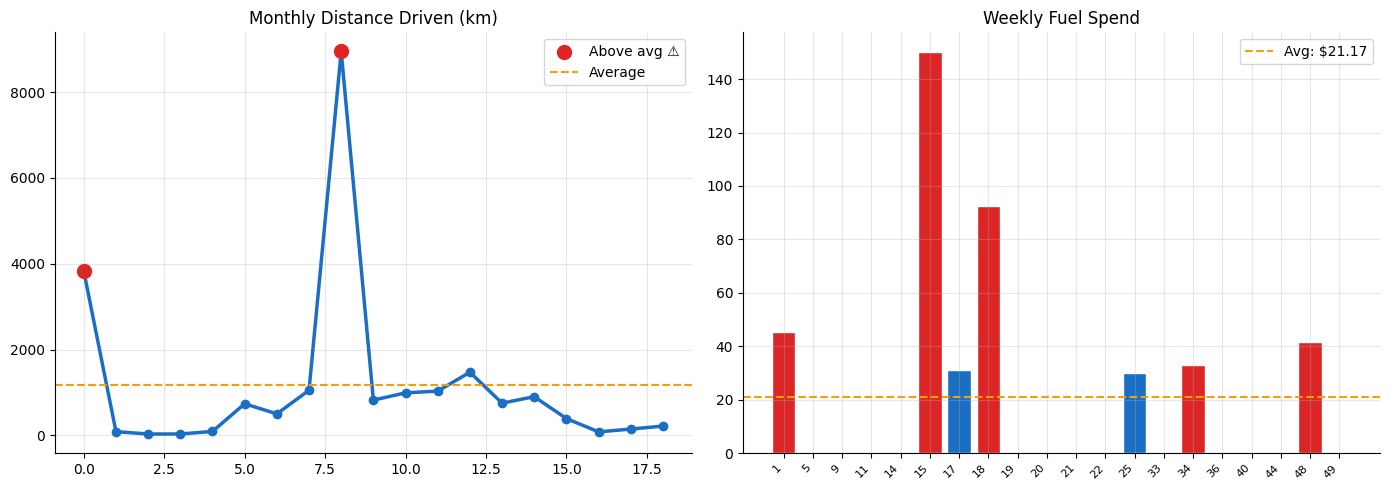

✅ Chart 4 saved


In [9]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(range(len(monthly)),monthly["monthly_km"],color=COLORS["normal"],linewidth=2.5,marker="o",markersize=6)
high_km = monthly["monthly_km"] > monthly["monthly_km"].mean()+monthly["monthly_km"].std()
if high_km.any():
    ax1.scatter([i for i,h in enumerate(high_km) if h],monthly[high_km]["monthly_km"],color=COLORS["anomaly"],zorder=5,s=100,label="Above avg ⚠")
ax1.axhline(monthly["monthly_km"].mean(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label="Average")
ax1.set_title("Monthly Distance Driven (km)"); ax1.legend()

weekly_clean = weekly.dropna()
if len(weekly_clean)>0:
    colors_w = [COLORS["anomaly"] if v>weekly_clean["weekly_fuel_cost"].mean()*1.5 else COLORS["normal"] for v in weekly_clean["weekly_fuel_cost"]]
    ax2.bar(weekly_clean["week"].astype(str),weekly_clean["weekly_fuel_cost"],color=colors_w,edgecolor="white")
    ax2.axhline(weekly_clean["weekly_fuel_cost"].mean(),color=COLORS["warning"],linestyle="--",linewidth=1.5,label=f"Avg: ${weekly_clean['weekly_fuel_cost'].mean():.2f}")
    ax2.legend(); ax2.set_title("Weekly Fuel Spend")
    plt.setp(ax2.get_xticklabels(),rotation=45,ha="right",fontsize=8)

plt.tight_layout()
plt.savefig("feat_chart4_temporal.png",dpi=150,bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

### Cell 9 — Chart 5: Feature correlation heatmap

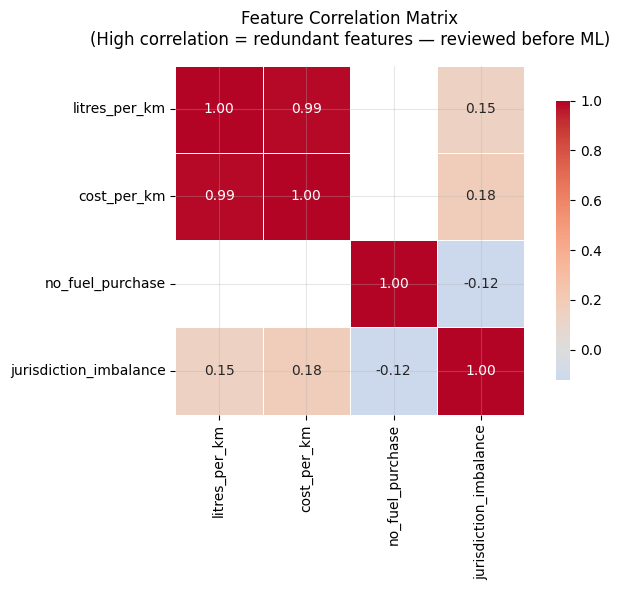

✅ Chart 5 saved

Correlation interpretation:
  ⚠ HIGH: litres_per_km vs cost_per_km: 0.99 → may be redundant
  ✅ LOW:  litres_per_km vs no_fuel_purchase: nan
  ✅ LOW:  litres_per_km vs jurisdiction_imbalance: 0.15
  ✅ LOW:  cost_per_km vs no_fuel_purchase: nan
  ✅ LOW:  cost_per_km vs jurisdiction_imbalance: 0.18
  ✅ LOW:  no_fuel_purchase vs jurisdiction_imbalance: -0.12


In [10]:
numeric_features = ["litres_per_km","cost_per_km","no_fuel_purchase","jurisdiction_imbalance","odometer_gap"]
existing = [f for f in numeric_features if f in df.columns]
corr     = df[existing].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True,linewidths=0.5,cbar_kws={"shrink":0.8},ax=ax)
ax.set_title("Feature Correlation Matrix\n(High correlation = redundant features — reviewed before ML)",pad=15)
plt.tight_layout()
plt.savefig("feat_chart5_correlation.png",dpi=150,bbox_inches="tight")
s3.upload_file("feat_chart5_correlation.png",BUCKET,"charts/features/feat_chart5_correlation.png")
plt.show()
print("✅ Chart 5 saved")

print("\nCorrelation interpretation:")
for i in range(len(corr.columns)):
    for j in range(i+1,len(corr.columns)):
        val  = corr.iloc[i,j]
        feat = f"{corr.columns[i]} vs {corr.columns[j]}"
        if abs(val)>0.7:   print(f"  ⚠ HIGH: {feat}: {val:.2f} → may be redundant")
        elif abs(val)>0.4: print(f"  ⚡ MOD:  {feat}: {val:.2f}")
        else:              print(f"  ✅ LOW:  {feat}: {val:.2f}")

### Cell 10 — Save all features and charts to S3

In [11]:
save_csv(df,                                "features/features.csv")
save_csv(jurisdiction_summary.reset_index(),"features/jurisdiction_summary.csv")
save_csv(monthly,                           "features/monthly_trends.csv")
save_csv(weekly,                            "features/weekly_trends.csv")

charts = ["feat_chart1_distributions.png","feat_chart2_fuel_match.png",
          "feat_chart3_jurisdiction.png","feat_chart4_temporal.png","feat_chart5_correlation.png"]
for chart in charts:
    if os.path.exists(chart):
        s3.upload_file(chart,BUCKET,f"charts/features/{chart}")
        print(f"✅ Uploaded → charts/features/{chart}")

print(f"\n{'='*55}")
print(f"03_features.ipynb COMPLETE!")
print(f"   Records:          {len(df)}")
print(f"   Fuel matched:     {df['fuel_match'].sum()}")
print(f"   No fuel purchase: {df['no_fuel_purchase'].sum()}")
print(f"Next → 04_ml.ipynb")

✅ Saved → s3://govofalbertaraw/features/features.csv
✅ Saved → s3://govofalbertaraw/features/jurisdiction_summary.csv
✅ Saved → s3://govofalbertaraw/features/monthly_trends.csv
✅ Saved → s3://govofalbertaraw/features/weekly_trends.csv
✅ Uploaded → charts/features/feat_chart1_distributions.png
✅ Uploaded → charts/features/feat_chart2_fuel_match.png
✅ Uploaded → charts/features/feat_chart3_jurisdiction.png
✅ Uploaded → charts/features/feat_chart4_temporal.png
✅ Uploaded → charts/features/feat_chart5_correlation.png

03_features.ipynb COMPLETE!
   Records:          40
   Fuel matched:     9
   No fuel purchase: 31
Next → 04_ml.ipynb
